In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.load_config import load_config
from utils.load_data import load_pkl
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.utils import resample

## Data loading

In [2]:
cfg = load_config()
driams_pkl = cfg["data"]["DRIAMS_REDUCED_PKL"]

In [3]:
driams = load_pkl(driams_pkl)

In [4]:
data, label, meta = driams["data"], driams["label"], driams["meta"]

In [5]:
meta = pd.DataFrame.from_records(list(meta))

## PCA

Normalize each spectrum

In [6]:
# axis=1 to work row by row
# keepdims=True keeps the dimensions needed for per-row normalization to work correctly
data_norm = (data - data.min(axis=1, keepdims=True)) / (
    data.max(axis=1, keepdims=True) - data.min(axis=1, keepdims=True) + 1e-8)

Reduce dimensionality (there are 6000 features)

In [ ]:
my_pca = PCA().fit(data_norm)

In [ ]:
# explained_variance_ returns the amount of variance explained by each of the selected components
# explained_variance_ratio_ returnd the percentage of variance explained by each of the selected components
cumulative_explained_var = np.cumsum(my_pca.explained_variance_)
cumulative_explained_var_ratio = np.cumsum(my_pca.explained_variance_ratio_)

In [ ]:
print(cumulative_explained_var)
print(cumulative_explained_var_ratio)

In [ ]:
plt.plot(np.arange(1, len(cumulative_explained_var_ratio)+1), cumulative_explained_var_ratio)
plt.axhline(0.9, color='r', linestyle='--')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")

In [ ]:
n_components = np.argmax(cumulative_explained_var_ratio >= 0.9) + 1
print(f"Number of components explaining 90% variance: {n_components}")

This indicates that 551 components are needed to account for 90% of the variance in our dataset. However, this is still a lot for t-SNE, so it is recommended to try and reduce the number of components

In [ ]:
possible_dims = [30, 50, 100]
for dim in possible_dims:
    pca = PCA(n_components=dim).fit(data_norm)
    print(f"Explained variance with {dim} components: {np.sum(pca.explained_variance_ratio_)}")

In [7]:
data_norm_pca = PCA(n_components=100).fit_transform(data_norm)

## t-SNE

In [8]:
my_tsne = TSNE(n_components=2)
data_tsne = my_tsne.fit_transform(data_norm_pca)

In [ ]:
n_samples = 10000
X_pca_sub, X_tsne_sub, y_sub = resample(
    data_norm_pca, data_tsne, label, n_samples=n_samples, stratify=label)

tw = trustworthiness(X_pca_sub, X_tsne_sub, n_neighbors=30)
print(f"Trustworthiness (10k stratified sample): {tw:.3f}")

## Visualization

### Label Encoding & DataFrame Creation  

In [9]:
# Identify unique labels
unique_labels = np.unique(label)
print(unique_labels)

# Assign a number to each label
label_to_idx = {}
for i in range(len(unique_labels)):
    label_to_idx[str(unique_labels[i])] = i
print(label_to_idx)

# Map label dataset 
encoded_label = np.array([label_to_idx[l] for l in label])
print(encoded_label)

['Enterobacter_cloacae_complex' 'Enterococcus_Faecium' 'Escherichia_Coli'
 'Klebsiella_Pneumoniae' 'Pseudomonas_Aeruginosa' 'Staphylococcus_Aureus']
{'Enterobacter_cloacae_complex': 0, 'Enterococcus_Faecium': 1, 'Escherichia_Coli': 2, 'Klebsiella_Pneumoniae': 3, 'Pseudomonas_Aeruginosa': 4, 'Staphylococcus_Aureus': 5}
[3 3 3 ... 0 0 0]


In [10]:
# Create a DataFrame combining coordinates and metadata
tsne_df = pd.DataFrame({
    "x": data_tsne[:, 0],
    "y": data_tsne[:, 1],
    "species": label,
    "year": meta["year"].astype(str), 
    "hospital": meta["hospital"].astype(str)
})

tsne_df

,x,y,species,year,hospital
0,53.100216,3.655418,Klebsiella_Pneumoniae,2018,DRIAMS_B
1,51.547932,-3.361934,Klebsiella_Pneumoniae,2018,DRIAMS_B
2,55.445736,-1.386225,Klebsiella_Pneumoniae,2018,DRIAMS_B
3,50.116810,-2.741931,Klebsiella_Pneumoniae,2018,DRIAMS_B
4,54.821304,18.143175,Klebsiella_Pneumoniae,2018,DRIAMS_B
...,...,...,...,...,...
39776,18.472345,50.440323,Enterobacter_cloacae_complex,2017,DRIAMS_A
39777,-7.546990,22.148193,Enterobacter_cloacae_complex,2018,DRIAMS_C
39778,-0.496232,17.998856,Enterobacter_cloacae_complex,2018,DRIAMS_C
39779,-7.346612,22.869812,Enterobacter_cloacae_complex,2018,DRIAMS_C


### Palettes and Label Orders

In [15]:
# Define categorical orders
species_sorted = sorted(tsne_df["species"].unique())
years_sorted = sorted(tsne_df["year"].unique(), key=lambda x: int(x))
hospitals_sorted = sorted(tsne_df["hospital"].unique())

# Base palette
tab10 = sns.color_palette("tab10")

# Species palette
species_color_map = {
    "Enterobacter_cloacae_complex": tab10[5],  
    "Enterococcus_Faecium": tab10[4],         
    "Escherichia_Coli": tab10[2],             
    "Klebsiella_Pneumoniae": tab10[3],         
    "Pseudomonas_Aeruginosa": tab10[0],       
    "Staphylococcus_Aureus": tab10[1],         
}
species_palette_dict = {sp: species_color_map[sp] for sp in species_sorted}

# Year palette (temporal order)
palette_year = sns.color_palette("tab10", len(years_sorted))
palette_year_dict = {y: palette_year[i] for i, y in enumerate(years_sorted)}

# Hospital palette (alphabetical order)
palette_hosp = sns.color_palette("tab10", len(hospitals_sorted))
palette_hosp_dict = {h: palette_hosp[i] for i, h in enumerate(hospitals_sorted)}

### Global t-SNE — Visualization by Species
Displays the overall t-SNE embedding colored by species to assess inter-species separation in spectral space.

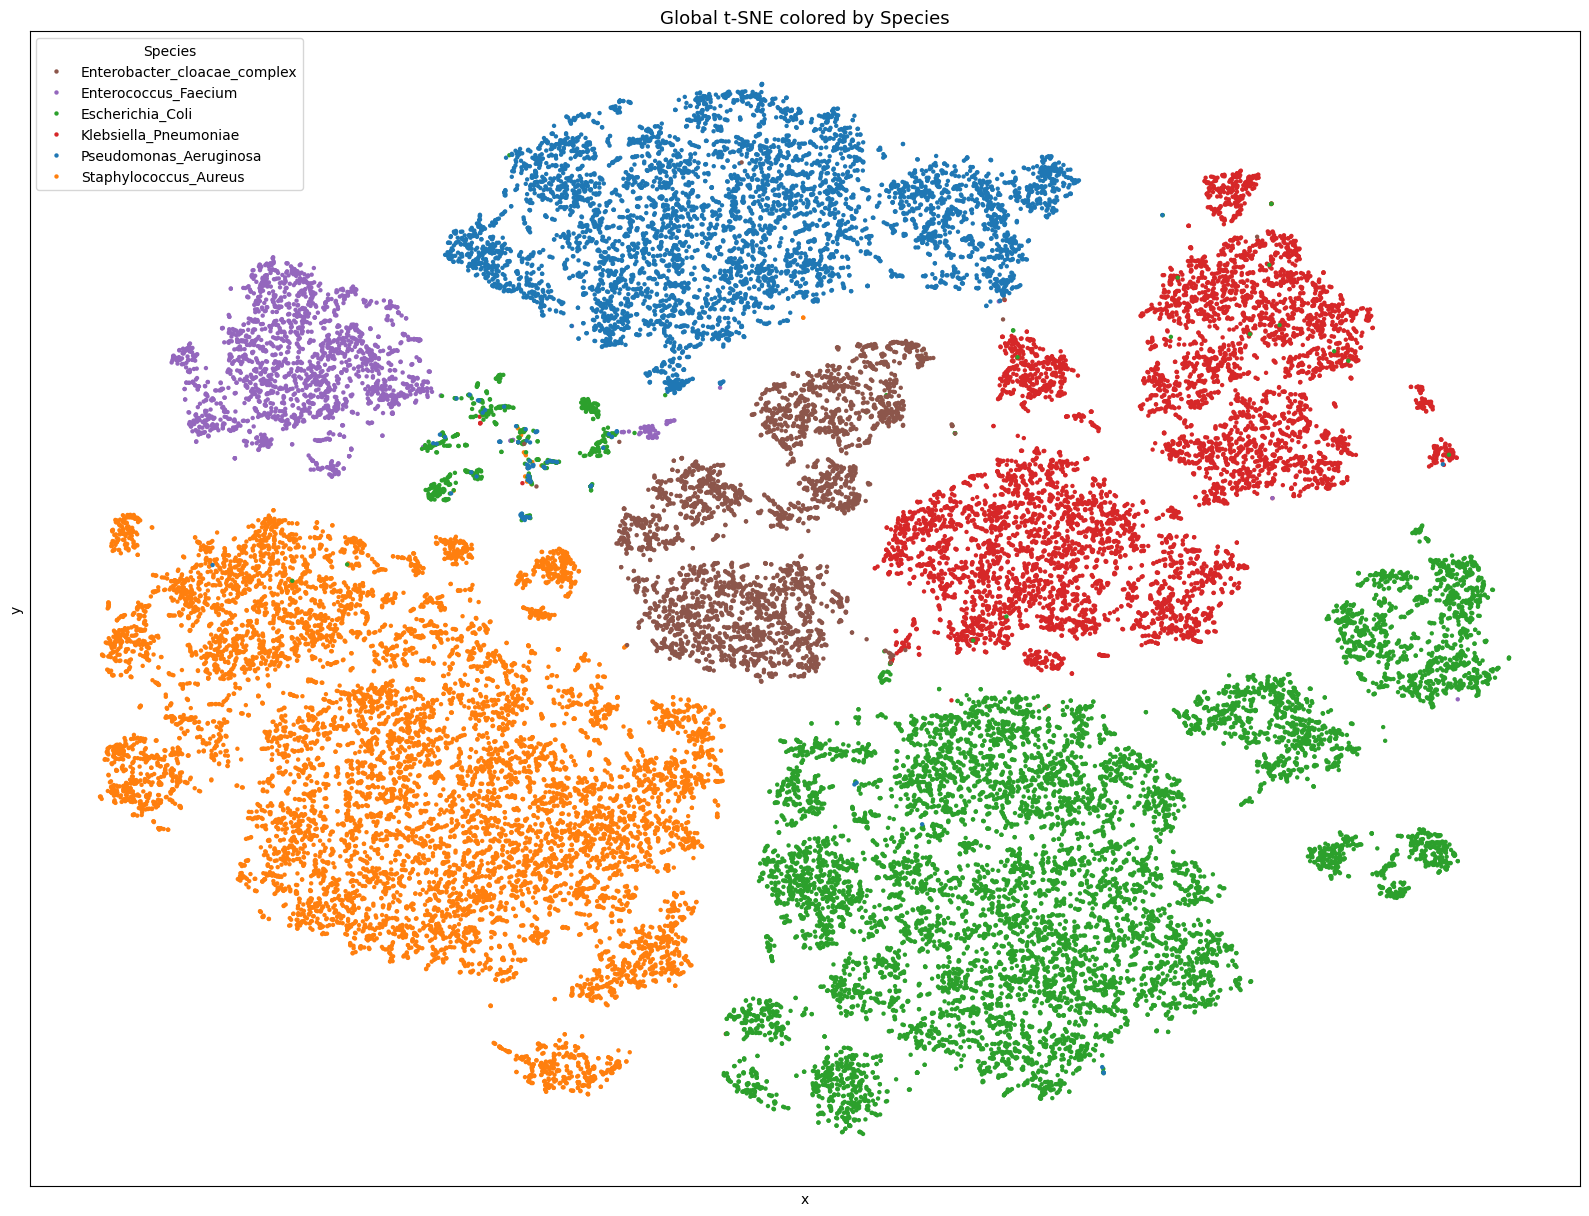

In [17]:
fig, ax = plt.subplots(figsize=(20, 15))
sns.scatterplot(
    data=tsne_df, x="x", y="y",
    hue="species", hue_order=species_sorted,
    palette=species_palette_dict,
    s=10, linewidth=0, ax=ax
)
ax.set_title("Global t-SNE colored by Species", fontsize=13)
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="upper left", title="Species")
plt.show()

### Global t-SNE — Visualization by Year
Shows the global temporal distribution of the dataset, coloring each sample by acquisition year to detect potential time shifts.


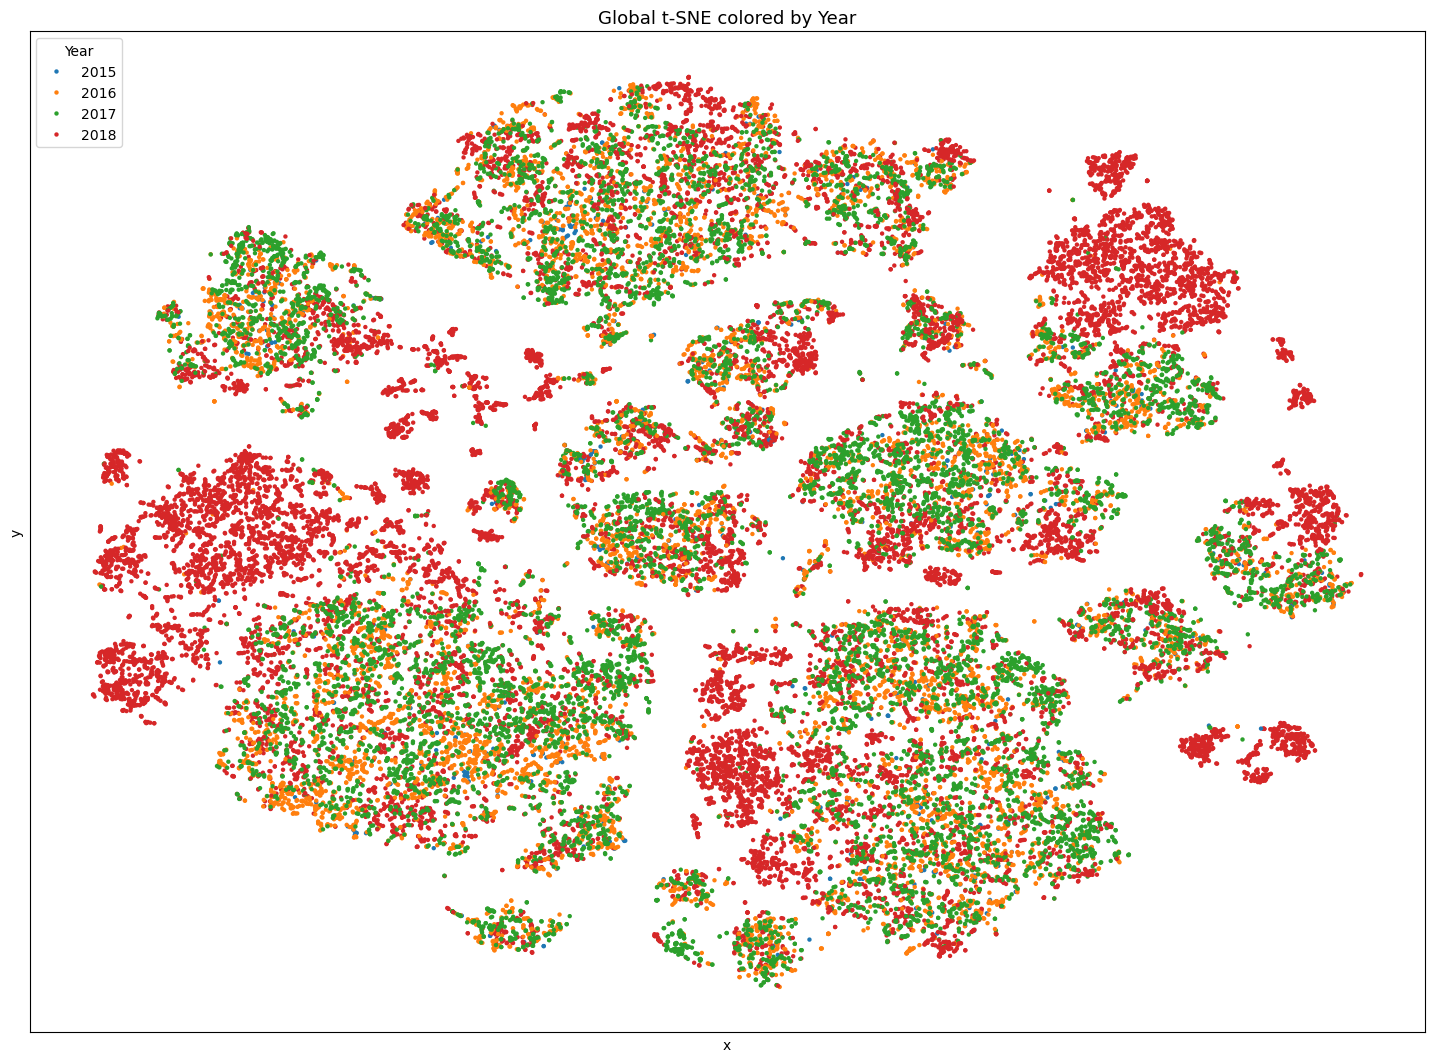

In [18]:
fig, ax = plt.subplots(figsize=(18, 13))
sns.scatterplot(
    data=tsne_df, x="x", y="y",
    hue="year", hue_order=years_sorted,
    palette=palette_year_dict,
    s=10, linewidth=0, ax=ax
)
ax.set_title("Global t-SNE colored by Year", fontsize=13)
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="upper left", title="Year")
plt.show()

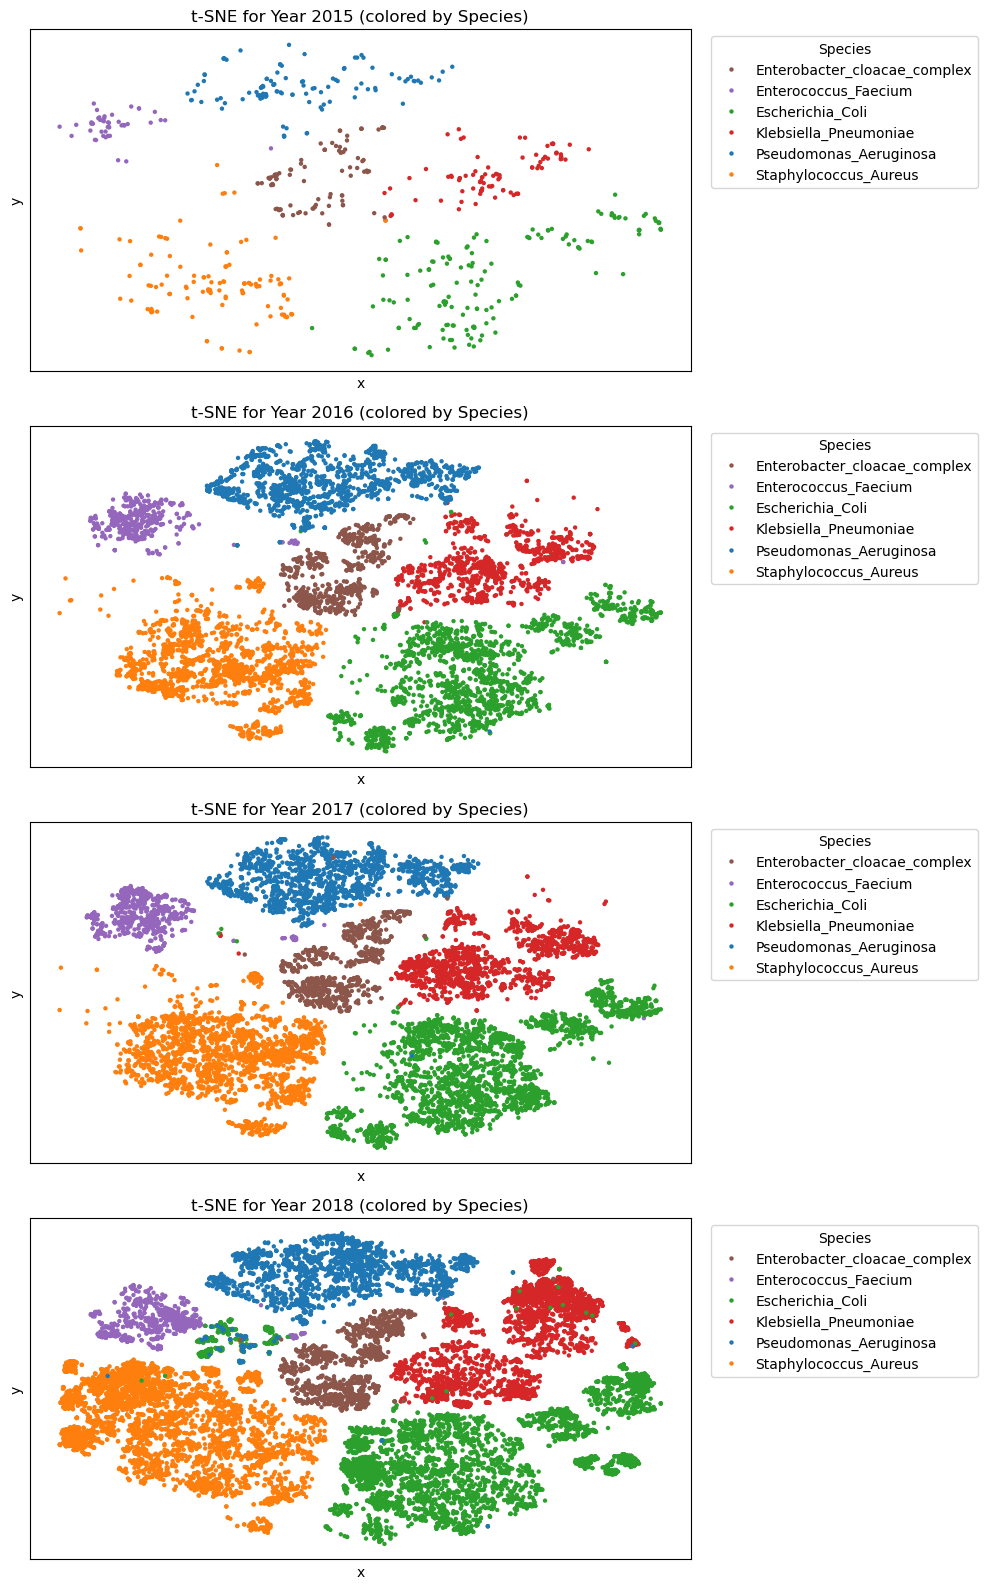

In [ ]:
fig, axes = plt.subplots(len(years_sorted), 1, figsize=(10, 4 * len(years_sorted)))

for i, year in enumerate(years_sorted):
    subset = tsne_df[tsne_df["year"] == year]
    sns.scatterplot(
        data=subset,
        x="x", y="y",
        hue="species",
        hue_order=species_sorted,
        palette=species_palette_dict,
        s=10, linewidth=0, ax=axes[i]
    )
    axes[i].set_title(f"t-SNE for Year {year} (colored by Species)", fontsize=12)
    axes[i].legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Species")
    axes[i].set_xticks([]); axes[i].set_yticks([])

plt.tight_layout()
plt.show()

### Global t-SNE — Visualization by Hospital
Displays the overall embedding colored by hospital to reveal potential inter-hospital domain shifts.

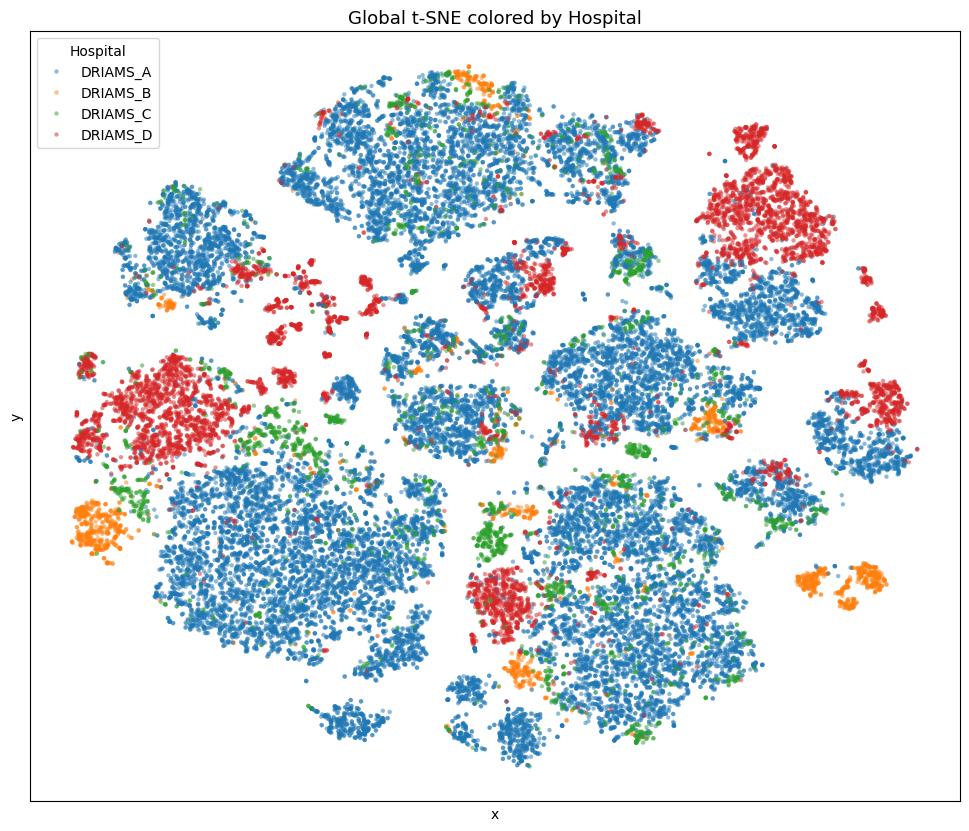

In [21]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.scatterplot(
    data=tsne_df, x="x", y="y",
    hue="hospital", hue_order=hospitals_sorted,
    palette=palette_hosp_dict,
    s=10, alpha=0.5, linewidth=0, ax=ax
)
ax.set_title("Global t-SNE colored by Hospital", fontsize=13)
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="upper left", title="Hospital")
plt.show()

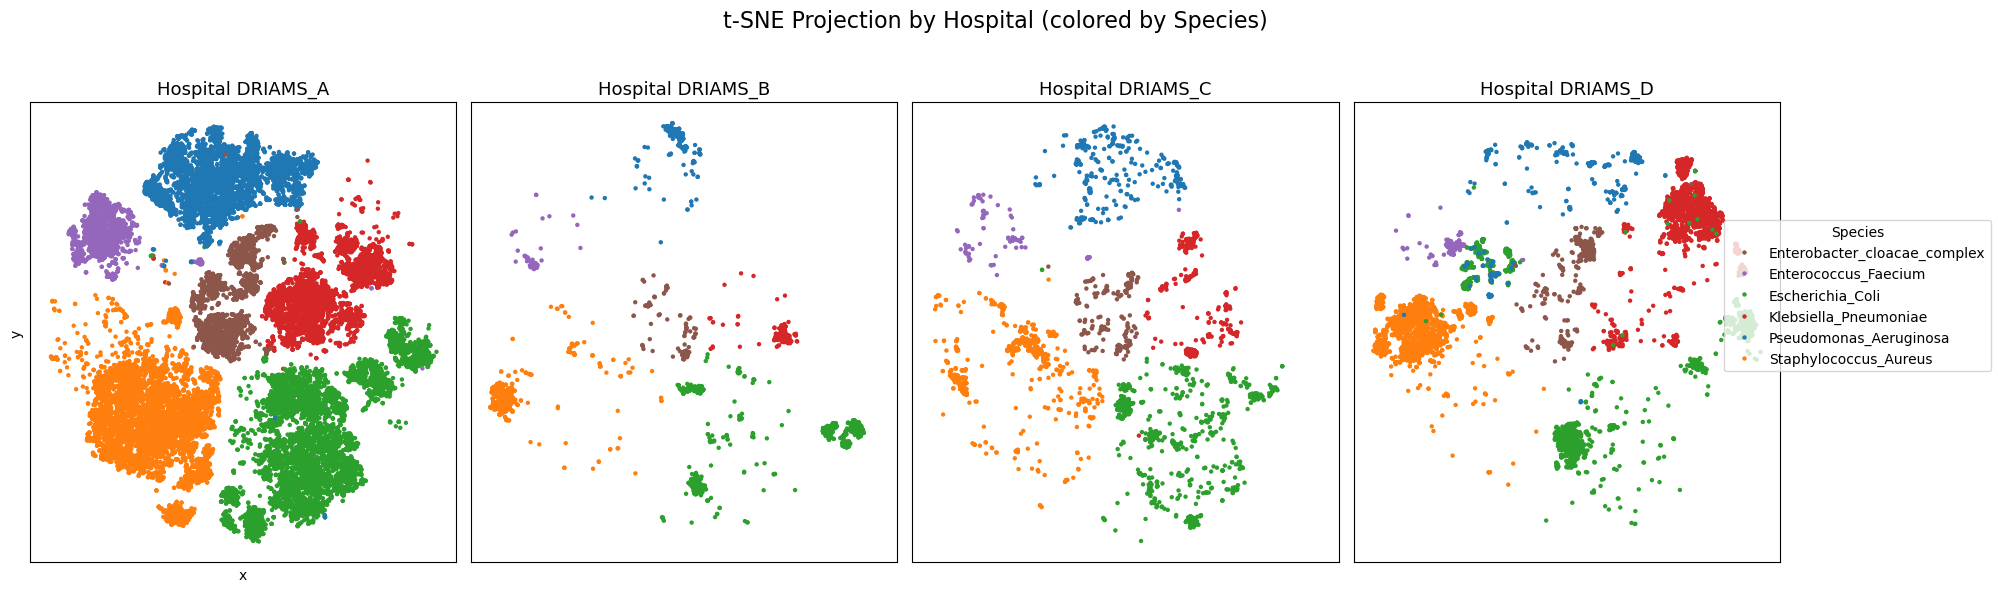

In [22]:
fig, axes = plt.subplots(1, len(hospitals_sorted), figsize=(5 * len(hospitals_sorted), 6), sharex=True, sharey=True)
axes = np.array(axes).flatten()

for i, hosp in enumerate(hospitals_sorted):
    subset = tsne_df[tsne_df["hospital"] == hosp]
    sns.scatterplot(
        data=subset,
        x="x", y="y",
        hue="species",
        hue_order=species_sorted,
        palette=species_palette_dict,
        s=10, linewidth=0, ax=axes[i]
    )
    axes[i].set_title(f"Hospital {hosp}", fontsize=13)
    axes[i].set_xticks([]); axes[i].set_yticks([])
    axes[i].legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", title="Species")

plt.suptitle("t-SNE Projection by Hospital (colored by Species)", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


### t-SNE per Species — Global Embedding colored by Hospital
Shows the global embedding filtered by species and colored by hospital to reveal intra-species domain shifts.


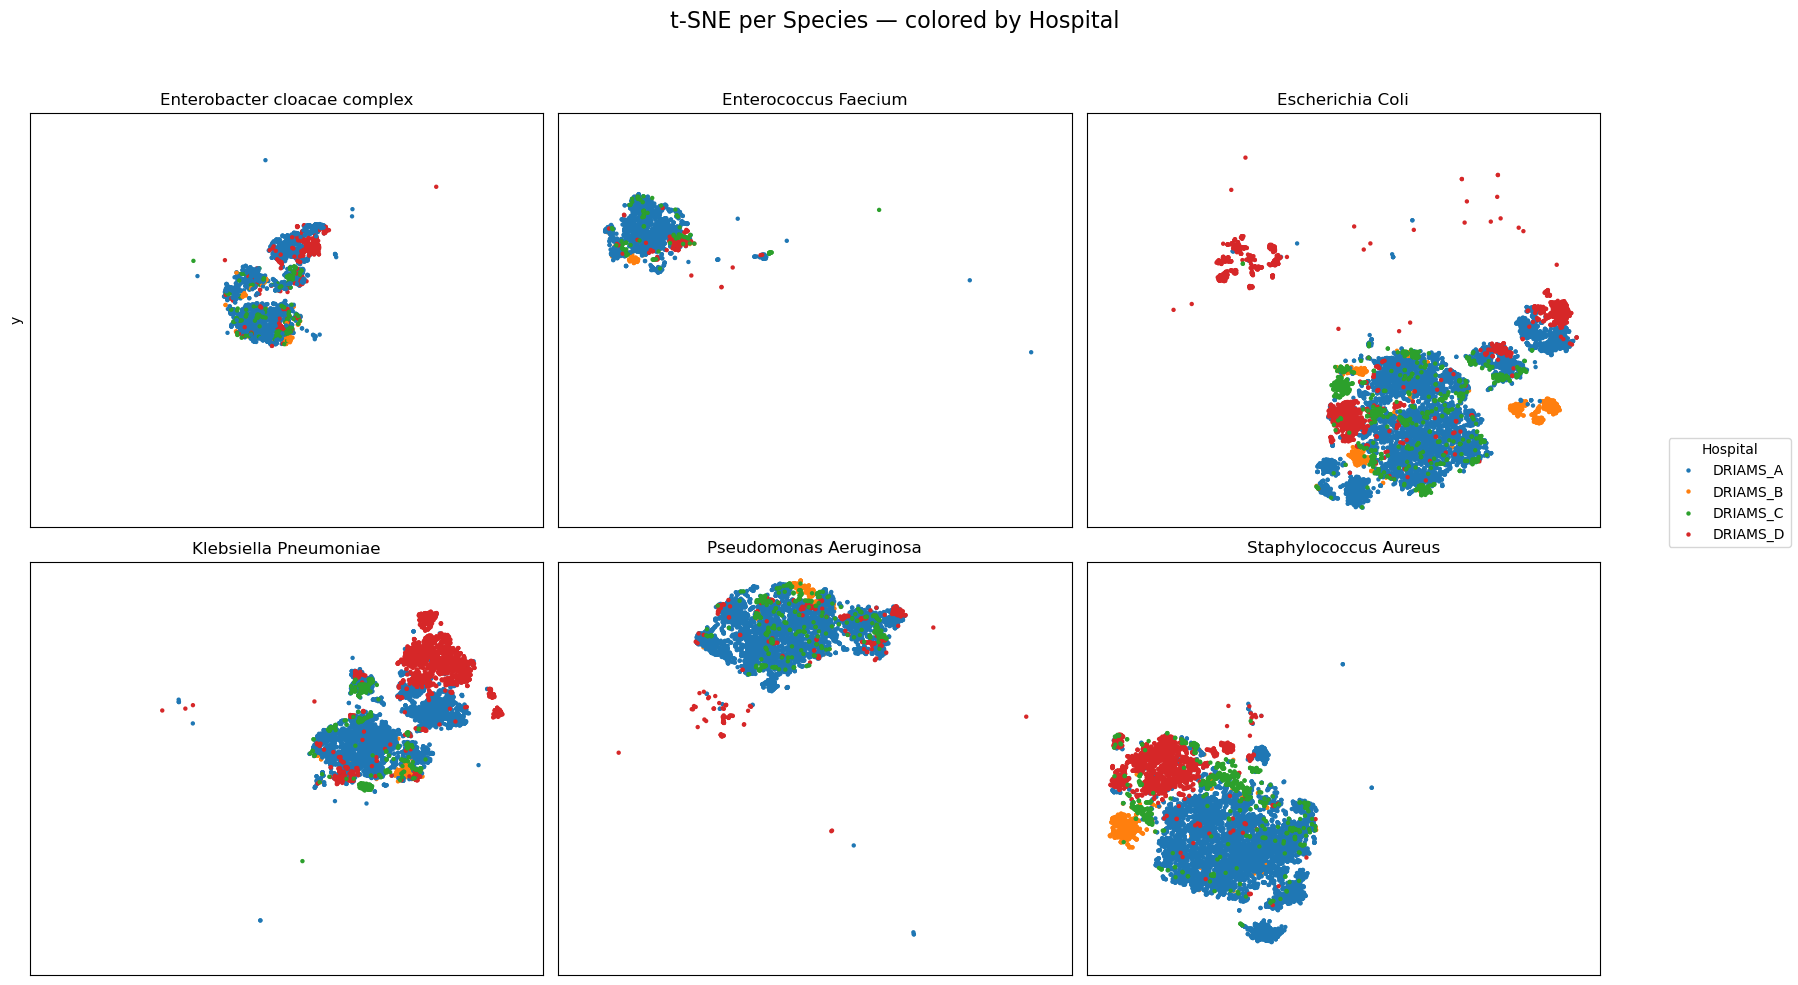

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, sp in enumerate(species_sorted):
    subset = tsne_df[tsne_df["species"] == sp]
    sns.scatterplot(
        data=subset,
        x="x", y="y",
        hue="hospital",
        hue_order=hospitals_sorted,
        palette=palette_hosp_dict,
        s=10, linewidth=0, ax=axes[i]
    )
    axes[i].set_title(sp.replace("_", " "), fontsize=12)
    axes[i].set_xticks([]); axes[i].set_yticks([])
    axes[i].legend_.remove()

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", title="Hospital")

plt.suptitle("t-SNE per Species — colored by Hospital", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()

### Independent t-SNE per Species — Inter-Hospital Domain Shift
Trains an independent t-SNE for each species, coloring points by hospital, to visually assess intra-species domain shifts across hospitals.


In [24]:
# ============================================================
# Compute and store independent t-SNE embeddings per species
# ============================================================
tsne_results = {}  # diccionario donde guardaremos resultados

species_sorted = sorted(np.unique(label))
palette_hosp = sns.color_palette("tab10", len(meta["hospital"].unique()))

for sp in species_sorted:
    mask = (label == sp)
    X = data_norm[mask]
    y_hosp = meta.loc[mask, "hospital"].values

    # PCA 
    X_pca = PCA(n_components=50).fit_transform(X)

    # t-SNE
    tsne = TSNE(n_components=2)
    X_tsne = tsne.fit_transform(X_pca)

    # Store in dictionary
    tsne_results[sp] = {
        "embedding": X_tsne,
        "hospital": y_hosp
    }

print(f"Stored {len(tsne_results)} t-SNE embeddings (one per species).")

Stored 6 t-SNE embeddings (one per species).


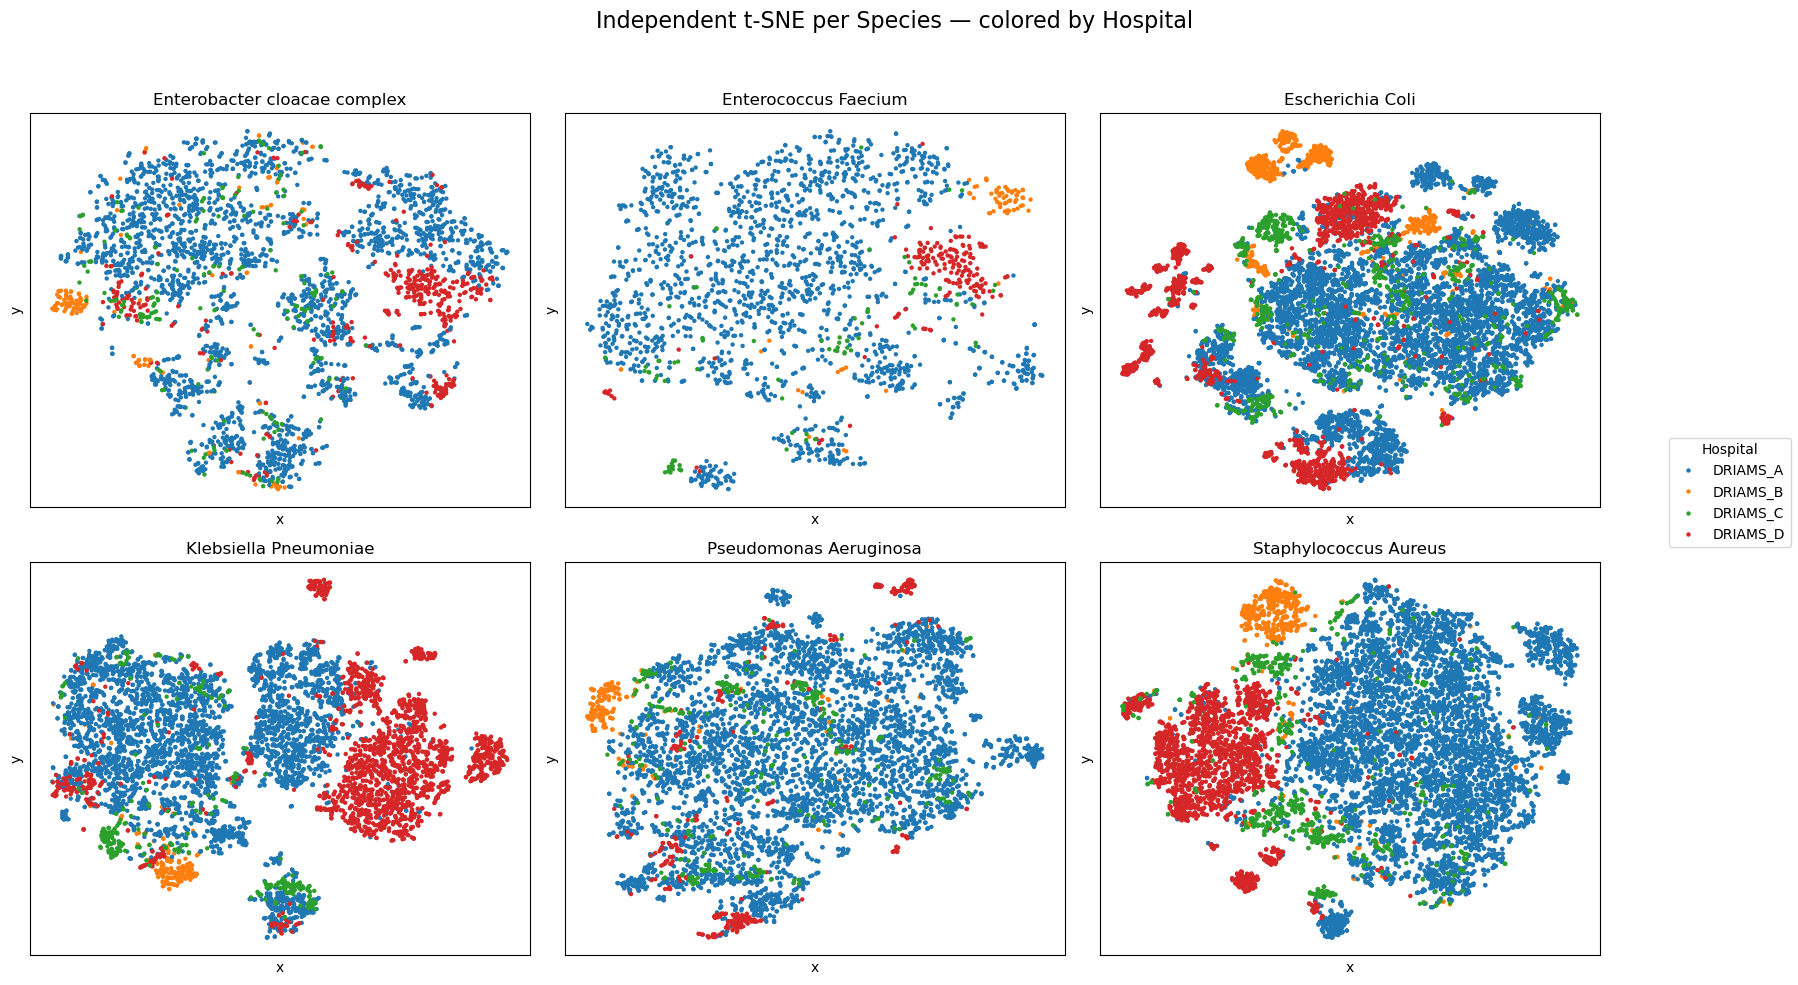

In [25]:
# ============================================================
# Plot the precomputed t-SNEs per species (colored by hospital)
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, sp in enumerate(species_sorted):
    data_sp = tsne_results[sp]
    X_tsne = data_sp["embedding"]
    y_hosp = data_sp["hospital"]

    df_sp = pd.DataFrame({
        "x": X_tsne[:, 0],
        "y": X_tsne[:, 1],
        "hospital": y_hosp
    })

    sns.scatterplot(
        data=df_sp, x="x", y="y",
        hue="hospital", hue_order=hospitals_sorted, palette=palette_hosp_dict,
        s=10, linewidth=0, ax=axes[i]
    )
    axes[i].set_title(sp.replace("_", " "), fontsize=12)
    axes[i].set_xticks([]); axes[i].set_yticks([])
    axes[i].legend_.remove()

# Ocultar subplots vacíos (si hubiera menos de 6 especies)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# Leyenda global
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", title="Hospital")

plt.suptitle("Independent t-SNE per Species — colored by Hospital", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()

En resumen, este gráfico muestra qué tan distintos son los hospitales entre sí dentro de cada especie,
y por tanto qué tan necesario será aplicar domain alignment específico por especie para lograr generalización cross-hospital.

### Independent t-SNE per Species — Temporal Distribution Analysis
Independent t-SNE per species colored by year, revealing potential intra-species time shifts in spectral representations across acquisition years.

In [26]:
# ============================================================
# Compute and store independent t-SNE embeddings per species (colored by year)
# ============================================================
tsne_results_year = {}
species_sorted = sorted(np.unique(label))
palette_year = sns.color_palette("tab10", len(meta["year"].unique()))

for sp in species_sorted:
    mask = (label == sp)
    X = data_norm[mask]
    y_year = meta.loc[mask, "year"].astype(str).values

    # PCA -> reduce to 50 components before t-SNE
    X_pca = PCA(n_components=50).fit_transform(X)

    # t-SNE
    tsne = TSNE(n_components=2)
    X_tsne = tsne.fit_transform(X_pca)

    # Store in dictionary
    tsne_results_year[sp] = {
        "embedding": X_tsne,
        "year": y_year
    }

print(f"Stored {len(tsne_results_year)} t-SNE embeddings (one per species, colored by year).")

Stored 6 t-SNE embeddings (one per species, colored by year).


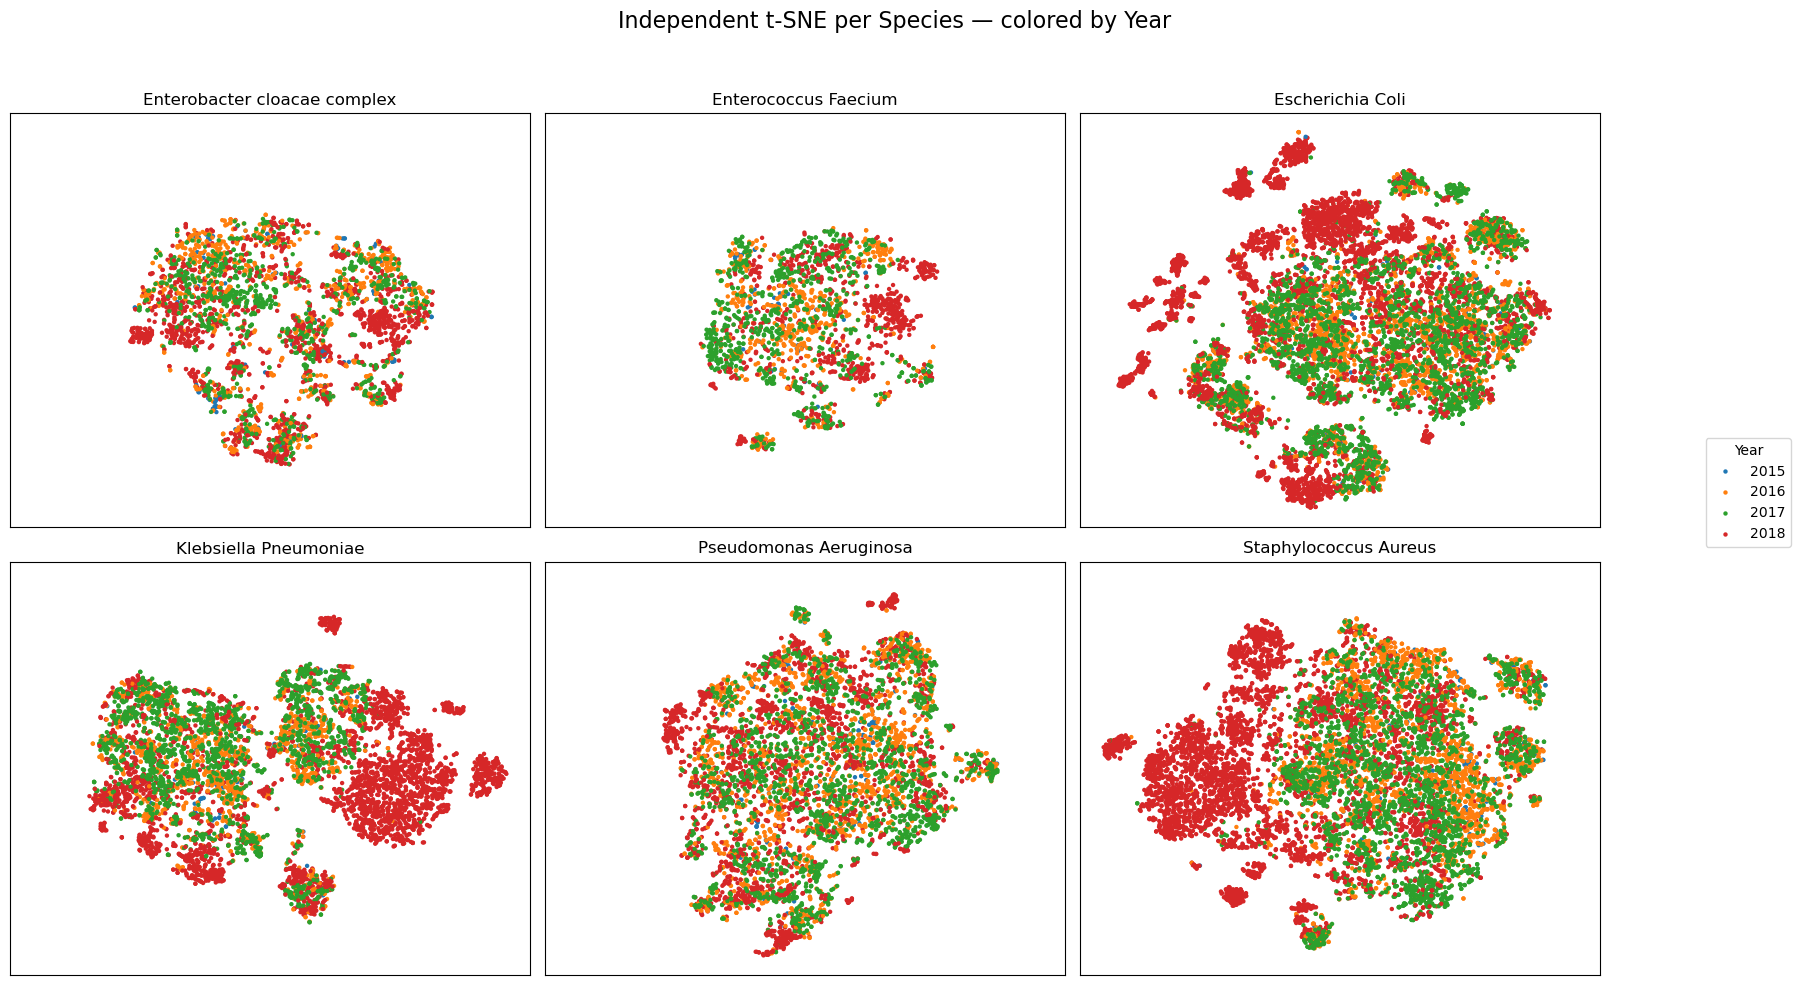

In [27]:
# ============================================================
# Visualization (2 rows × 3 columns layout)
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

# Asegurar orden cronológico de los años
years_sorted = sorted(meta["year"].astype(str).unique(), key=lambda x: int(x))
palette_year_dict = {y: palette_year[i % len(palette_year)] for i, y in enumerate(years_sorted)}

for i, sp in enumerate(species_sorted):
    emb = tsne_results_year[sp]["embedding"]
    y_year = tsne_results_year[sp]["year"]

    sns.scatterplot(
        x=emb[:, 0], y=emb[:, 1],
        hue=y_year,
        hue_order=years_sorted,
        palette=palette_year_dict,
        s=10, linewidth=0, ax=axes[i]
    )

    axes[i].set_title(sp.replace("_", " "), fontsize=12)
    axes[i].set_xticks([]); axes[i].set_yticks([])
    axes[i].legend_.remove()

# Ocultar subplots vacíos (por si hay menos de 6 especies)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# Leyenda global
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", title="Year")

plt.suptitle("Independent t-SNE per Species — colored by Year", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()